# Phase 5 — Applicability Domain + Error-Link Validation

Define an **applicability domain (AD)** for the surrogate and test the core hypothesis: **does distance from the training domain predict surrogate error?** We generate probe points outside the training box, run **real SWMM** on them, and correlate |error| with AD distance.

Design: `docs/superpowers/specs/2026-09-05-phase5-applicability-domain-design.md`.

## 1. Config, models, SWMM helpers

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

def _find_root(marker="PROJECT_BRIEF.md"):
    here = Path.cwd()
    for cand in [here, *here.parents]:
        if (cand / marker).exists():
            return cand
    return here

PROJECT    = _find_root()
DATA_DIR   = PROJECT / "data"
MODELS_DIR = PROJECT / "models"
RUNS_DIR   = PROJECT / "runs"; RUNS_DIR.mkdir(exist_ok=True)
SWMM_EXE   = Path(r"D:\EPA SWMM 5.2.4 (64-bit)\runswmm.exe")
BASE_INP   = PROJECT / "swmm" / "base_model.inp"
SEED = 42

# reusable SWMM helpers
sys.path.insert(0, str(PROJECT / "scripts"))
from swmm_utils import write_scenario, run_swmm, parse_rpt

FEATURES = ["rain_mult", "imperv_mult", "surf_n", "infil_min", "pipe_n"]

df = pd.read_csv(DATA_DIR / "dataset.csv")
df = df[df["status"] == "ok"].reset_index(drop=True)
Xtrain = df[FEATURES].values

peak_reg = joblib.load(MODELS_DIR / "peak_regressor.joblib")
print("Training scenarios:", len(df), "| loaded peak surrogate")
assert SWMM_EXE.exists(), f"runswmm.exe not found at {SWMM_EXE}"

Training scenarios: 500 | loaded peak surrogate


## 2. Define the applicability domain

Three AD notions fit on the training features: **range** (min-max box, weak baseline), **Mahalanobis** distance (raw features, captures correlations, scale-invariant), and **k-NN** distance (mean standardized distance to the 10 nearest training points).

In [2]:
from sklearn.neighbors import NearestNeighbors
from scipy.stats import chi2

# --- Range baseline ---
lo, hi = Xtrain.min(0), Xtrain.max(0)
def in_range(X):
    X = np.asarray(X)
    return ((X >= lo) & (X <= hi)).all(axis=1)

# --- Mahalanobis (raw features) ---
mu    = Xtrain.mean(0)
Sigma = np.cov(Xtrain, rowvar=False)
Sig_inv = np.linalg.inv(Sigma)
def mahalanobis(X):
    D = np.asarray(X) - mu
    return np.sqrt(np.einsum("ij,jk,ik->i", D, Sig_inv, D))

# --- k-NN (standardized features) ---
K  = 10
sd = Xtrain.std(0)
def zscore(X):
    return (np.asarray(X) - mu) / sd
nn = NearestNeighbors(n_neighbors=K).fit(zscore(Xtrain))
def knn_dist(X):
    d, _ = nn.kneighbors(zscore(X))
    return d.mean(axis=1)

# --- thresholds = 99th percentile of the training distribution ---
MD_THR  = np.percentile(mahalanobis(Xtrain), 99)
KNN_THR = np.percentile(knn_dist(Xtrain), 99)
print(f"Mahalanobis threshold (99th pct train): {MD_THR:.3f}   "
      f"[chi2 df=5, 99% ref = {np.sqrt(chi2.ppf(0.99, df=5)):.3f}]")
print(f"kNN threshold (99th pct train):         {KNN_THR:.3f}")

Mahalanobis threshold (99th pct train): 3.179   [chi2 df=5, 99% ref = 3.884]
kNN threshold (99th pct train):         1.323


## 3. AD coverage of the Monte Carlo

How much of the 50k-sample Monte Carlo is inside the AD? Range should say ~100% (MC was drawn inside the ranges); Mahalanobis/kNN should flag some unusual corner combinations.

In [3]:
mc = pd.read_csv(DATA_DIR / "mc_results.csv")
Xmc = mc[FEATURES].values

cov_range = in_range(Xmc).mean()
cov_md    = (mahalanobis(Xmc) <= MD_THR).mean()
cov_knn   = (knn_dist(Xmc)    <= KNN_THR).mean()

print(f"AD coverage of {len(mc):,} MC samples:")
print(f"  range-based : {cov_range*100:5.1f}%")
print(f"  Mahalanobis : {cov_md*100:5.1f}%")
print(f"  kNN         : {cov_knn*100:5.1f}%")

AD coverage of 50,000 MC samples:
  range-based :  99.4%
  Mahalanobis :  98.8%
  kNN         :  92.3%


## 4. Probe points + real SWMM ground truth

Sample ~300 points from a box 50% wider than the training range each side (clipped to physical limits), run each through SWMM, and compare the surrogate's peak-discharge prediction against the SWMM truth.

In [4]:
WIDEN, N_PROBE = 1.5, 300
center, half = (lo + hi) / 2, (hi - lo) / 2
wlo, whi = center - WIDEN * half, center + WIDEN * half

rng = np.random.default_rng(SEED)
P = rng.uniform(wlo, whi, size=(N_PROBE, len(FEATURES)))

# physical clips (keep SWMM-valid)
idx = {f: i for i, f in enumerate(FEATURES)}
P[:, idx["rain_mult"]]   = np.clip(P[:, idx["rain_mult"]],   0.1,  None)
P[:, idx["imperv_mult"]] = np.clip(P[:, idx["imperv_mult"]], 0.1,  None)
P[:, idx["surf_n"]]      = np.clip(P[:, idx["surf_n"]],      0.005, None)
P[:, idx["infil_min"]]   = np.clip(P[:, idx["infil_min"]],   0.01, 4.0)   # < Horton MaxRate
P[:, idx["pipe_n"]]      = np.clip(P[:, idx["pipe_n"]],      0.005, None)

probes = pd.DataFrame(P, columns=FEATURES)

base_text = BASE_INP.read_text()
truth = []
for i, row in probes.iterrows():
    inp = RUNS_DIR / f"probe_{i:03d}.inp"
    inp.write_text(write_scenario(base_text, row.to_dict()))
    rpt, out, proc = run_swmm(inp, SWMM_EXE)
    truth.append(parse_rpt(rpt.read_text())["peak_discharge_cfs"] if rpt.exists() else np.nan)
    if out.exists():
        out.unlink()

probes["swmm_peak"]   = truth
probes["pred_peak"]   = peak_reg.predict(probes[FEATURES])
probes["abs_err"]     = (probes["swmm_peak"] - probes["pred_peak"]).abs()
probes["mahalanobis"] = mahalanobis(probes[FEATURES].values)
probes["knn_dist"]    = knn_dist(probes[FEATURES].values)
probes["in_range"]    = in_range(probes[FEATURES].values)

probes = probes.dropna(subset=["swmm_peak"]).reset_index(drop=True)
print(f"{len(probes)} probes ran | {(~probes['in_range']).sum()} outside training range")
print(f"mean |error|: {probes['abs_err'].mean():.3f} CFS")

300 probes ran | 261 outside training range
mean |error|: 1.556 CFS


## 5. Does AD distance predict error?

The core test: correlate |error| against each AD distance, and compare in-range vs out-of-range error.

In [5]:
from scipy.stats import spearmanr, pearsonr

for metric in ["mahalanobis", "knn_dist"]:
    rho, p_s = spearmanr(probes[metric], probes["abs_err"])
    r,   p_p = pearsonr(probes[metric], probes["abs_err"])
    print(f"{metric:12s}  Spearman rho={rho:.3f} (p={p_s:.1e})   Pearson r={r:.3f}")

print(f"\nmean |error| in-range  : {probes.loc[probes['in_range'],  'abs_err'].mean():.3f} CFS")
print(f"mean |error| out-range : {probes.loc[~probes['in_range'], 'abs_err'].mean():.3f} CFS")

# quintile-binned mean error vs Mahalanobis distance
probes["md_quintile"] = pd.qcut(probes["mahalanobis"], 5, labels=[1, 2, 3, 4, 5])
print("\nMean |error| by Mahalanobis-distance quintile (1=closest, 5=farthest):")
print(probes.groupby("md_quintile", observed=True)["abs_err"].mean().round(3))

mahalanobis   Spearman rho=0.522 (p=2.1e-22)   Pearson r=0.492
knn_dist      Spearman rho=0.551 (p=3.2e-25)   Pearson r=0.538

mean |error| in-range  : 0.357 CFS
mean |error| out-range : 1.735 CFS

Mean |error| by Mahalanobis-distance quintile (1=closest, 5=farthest):
md_quintile
1    0.493
2    1.117
3    1.358
4    2.016
5    2.797
Name: abs_err, dtype: float64


### Error vs AD distance

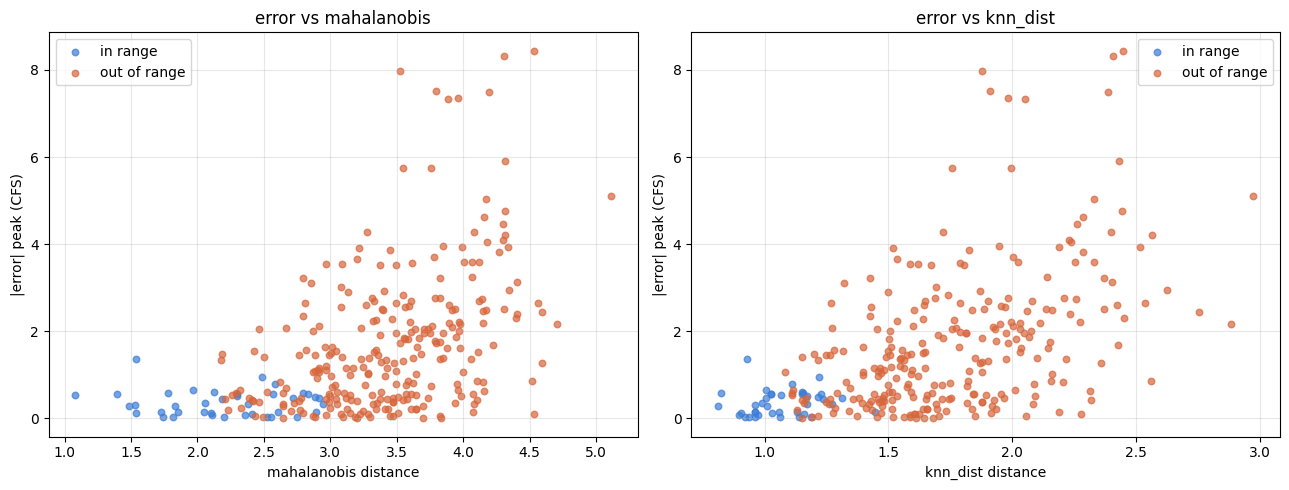

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, metric in zip(ax, ["mahalanobis", "knn_dist"]):
    inb = probes["in_range"]
    a.scatter(probes.loc[inb, metric],  probes.loc[inb, "abs_err"],
              s=22, c="#3b7dd8", alpha=0.7, label="in range")
    a.scatter(probes.loc[~inb, metric], probes.loc[~inb, "abs_err"],
              s=22, c="#d8663b", alpha=0.7, label="out of range")
    a.set_xlabel(f"{metric} distance"); a.set_ylabel("|error| peak (CFS)")
    a.set_title(f"error vs {metric}"); a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Practical payoff — AD as a trust filter

If we only trust predictions inside the AD (Mahalanobis threshold), how much lower is the error?

In [7]:
in_ad = probes["mahalanobis"] <= MD_THR
print(f"probes inside AD (Mahalanobis <= {MD_THR:.2f}): {int(in_ad.sum())}/{len(probes)}")
print(f"  mean |error| ALL    : {probes['abs_err'].mean():.3f} CFS")
print(f"  mean |error| in-AD  : {probes.loc[in_ad,  'abs_err'].mean():.3f} CFS")
print(f"  mean |error| out-AD : {probes.loc[~in_ad, 'abs_err'].mean():.3f} CFS")
if in_ad.any() and (~in_ad).any():
    ratio = probes.loc[~in_ad, "abs_err"].mean() / probes.loc[in_ad, "abs_err"].mean()
    print(f"  -> out-of-AD predictions are ~{ratio:.1f}x worse")

probes inside AD (Mahalanobis <= 3.18): 123/300
  mean |error| ALL    : 1.556 CFS
  mean |error| in-AD  : 0.802 CFS
  mean |error| out-AD : 2.080 CFS
  -> out-of-AD predictions are ~2.6x worse


## 7. Save results

In [8]:
probes.to_csv(DATA_DIR / "ad_probes.csv", index=False)
pd.DataFrame([
    {"metric": "range",       "MC_coverage_pct": round(cov_range*100, 2), "threshold": np.nan},
    {"metric": "mahalanobis", "MC_coverage_pct": round(cov_md*100, 2),    "threshold": round(MD_THR, 3)},
    {"metric": "knn",         "MC_coverage_pct": round(cov_knn*100, 2),   "threshold": round(KNN_THR, 3)},
]).to_csv(DATA_DIR / "ad_coverage.csv", index=False)
print("Saved -> data/ad_probes.csv, data/ad_coverage.csv")

Saved -> data/ad_probes.csv, data/ad_coverage.csv
